First 5 Rows:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0 

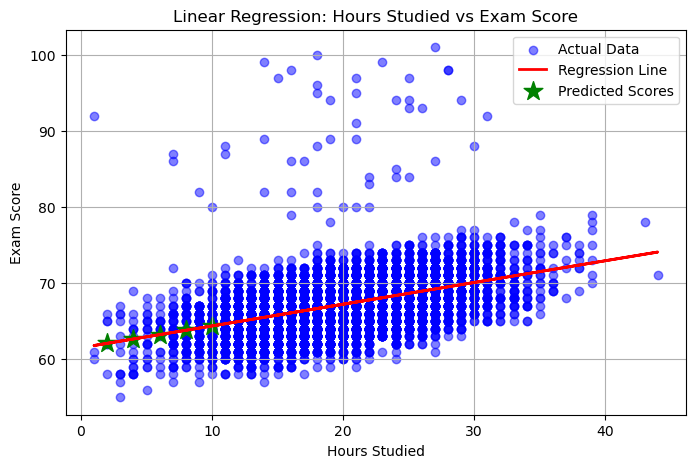

In [1]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 2: Load Dataset
df = pd.read_csv("StudentPerformanceFactors.csv")

# Step 3: Display Dataset Information
print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

# Step 4: Select Feature and Target
X = df[['Hours_Studied']]
y = df['Exam_Score']

# Step 5: Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Predict on Test Data
y_pred = model.predict(X_test)

# Step 8: Evaluate Model
print("\nModel Evaluation")
print("---------------------------")
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("Mean Absolute Error:", round(mean_absolute_error(y_test, y_pred), 2))
print("Mean Squared Error:", round(mean_squared_error(y_test, y_pred), 2))

# Step 9: Predict New Student Scores
new_students = pd.DataFrame({
    "Hours_Studied": [2, 4, 6, 8, 10]
})

predicted_scores = model.predict(new_students)

prediction_table = pd.DataFrame({
    "Hours Studied": new_students["Hours_Studied"],
    "Predicted Exam Score": predicted_scores.round(2)
})

print("\nPredicted Scores")
print(prediction_table)

# Step 10: Plot Regression Line
plt.figure(figsize=(8,5))

# Actual Data
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')

# Regression Line
plt.plot(X, model.predict(X), color='red', linewidth=2,
         label='Regression Line')

# Predicted Points
plt.scatter(new_students["Hours_Studied"],
            predicted_scores,
            color='green',
            marker='*',
            s=200,
            label='Predicted Scores')

plt.title("Linear Regression: Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.grid(True)

plt.show()